Strategi yang dibandingkan:

1. **Equally Weighted (EW)** — Portofolio naif 1/N, bobot seragam untuk semua aset.
2. **Classical Markowitz (CM)** — Optimasi Mean-Variance tradisional dengan minimasi varians portofolio.
3. **Glasso Markowitz (GM)** — Markowitz dengan regularisasi *Graphical Lasso* pada matriks kovarians.
4. **Network Markowitz (NW)** — Integrasi RMT dan MST ke dalam fungsi objektif Markowitz, dengan parameter penalti $\gamma$.
   * **Statis:** $\gamma = 0$ (tanpa penalti jaringan), $\gamma = 1.0$, dan $\gamma = 2.0$
   * **Adaptif — Window 120 hari (baseline):**
     * **NW (Risk GS)** — Optimasi $\gamma$ dengan minimasi risiko (variance) pada data validasi.
     * **NW (Return GS)** — Optimasi $\gamma$ dengan maksimalisasi return pada data validasi.
   * **Adaptif — Window Pendek (NW Adaptis):** Variasi rolling window yang lebih pendek untuk meningkatkan responsivitas terhadap perubahan pasar. Semua variasi menggunakan titik mulai backtest yang sama (*fair comparison*, `MAX_WINDOW = 120` hari).
     * **NW Adaptis 30 (Risk GS)** — Window 30 hari, minimasi risiko.
     * **NW Adaptis 30 (Return GS)** — Window 30 hari, maksimalisasi return.
     * **NW Adaptis 60 (Risk GS)** — Window 60 hari, minimasi risiko.
     * **NW Adaptis 60 (Return GS)** — Window 60 hari, maksimalisasi return.
     * **NW Adaptis 90 (Risk GS)** — Window 90 hari, minimasi risiko.
     * **NW Adaptis 90 (Return GS)** — Window 90 hari, maksimalisasi return.

---
## Sel 1 — Persiapan Library

Mengimpor semua library yang diperlukan untuk analisis jaringan, optimasi portofolio, dan visualisasi.

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.optimize import minimize
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.linalg import eigh
from sklearn.covariance import GraphicalLassoCV
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


---
## Sel 2 — Memuat Data

Memuat data return dan harga dari file Excel. Fokus pada dataset return harian untuk **10 aset kripto utama** dalam periode **14 September 2017 – 17 Oktober 2019**.

In [109]:
# Load data
excel_file = 'crypto_data_real.xlsx'
df_returns = pd.read_excel(excel_file, sheet_name='Returns', index_col=0)
df_prices  = pd.read_excel(excel_file, sheet_name='Prices',  index_col=0)

crypto_names = df_returns.columns.tolist()
n_assets     = len(crypto_names)

print(f"Data loaded: {df_returns.shape[0]} days, {n_assets} assets")
print(f"Period: {df_returns.index[0]} to {df_returns.index[-1]}")

Data loaded: 763 days, 10 assets
Period: 2017-09-15 00:00:00 to 2019-10-17 00:00:00


---
## Sel 3 — Statistik Ringkasan (Summary Statistics)

Tabel statistik deskriptif mencakup Mean, Standar Deviasi, Kurtosis, dan Skewness untuk setiap aset kripto (mereplikasi **Tabel 1** pada paper acuan).

In [110]:
# Create summary statistics table
summary_stats = pd.DataFrame({
    'Mean':     df_returns.mean(),
    'Std':      df_returns.std(),
    'Kurtosis': df_returns.kurt(),
    'Skewness': df_returns.skew()
})

print("TABLE 1 | Summary statistics.")
print(summary_stats.round(4))

TABLE 1 | Summary statistics.
        Mean     Std  Kurtosis  Skewness
BTC   0.0012  0.0434    3.0822    0.0523
ETH  -0.0008  0.0507    2.8209   -0.2916
XRP   0.0004  0.0654   18.9009    2.0588
USDT -0.0000  0.0057   21.7209    0.7437
BCH  -0.0014  0.0724    7.5671    0.6231
LTC   0.0004  0.0585    6.6357    1.0988
BNB   0.0029  0.0621   10.2612    1.0694
EOS   0.0012  0.0709    4.7582    0.5781
XLM   0.0006  0.0657    7.0332    0.9799
TRX   0.0025  0.0879   22.1856    2.6905


**Analisis Tabel 1:** Data menunjukkan bahwa sebagian besar aset kripto memiliki nilai *kurtosis* yang sangat tinggi (di atas 3), terutama TRX (22.18) dan XRP (18.90). Hal ini mengonfirmasi sifat *heavy-tailed* dari distribusi return kripto, di mana risiko ekstrem lebih sering terjadi dibandingkan distribusi normal. Nilai *Mean* yang mendekati nol mencerminkan efisiensi pasar secara rata-rata, namun volatilitas (*Std*) yang tinggi (rata-rata > 4%) menunjukkan risiko investasi yang sangat besar.

---
## Sel 4 — Visualisasi Harga Ternormalisasi (Figure 1 & 2)

Mereplikasi *Normalized cryptocurrency price series* dengan mengatur harga awal setiap aset menjadi **100** pada tanggal **7 Januari 2018**.

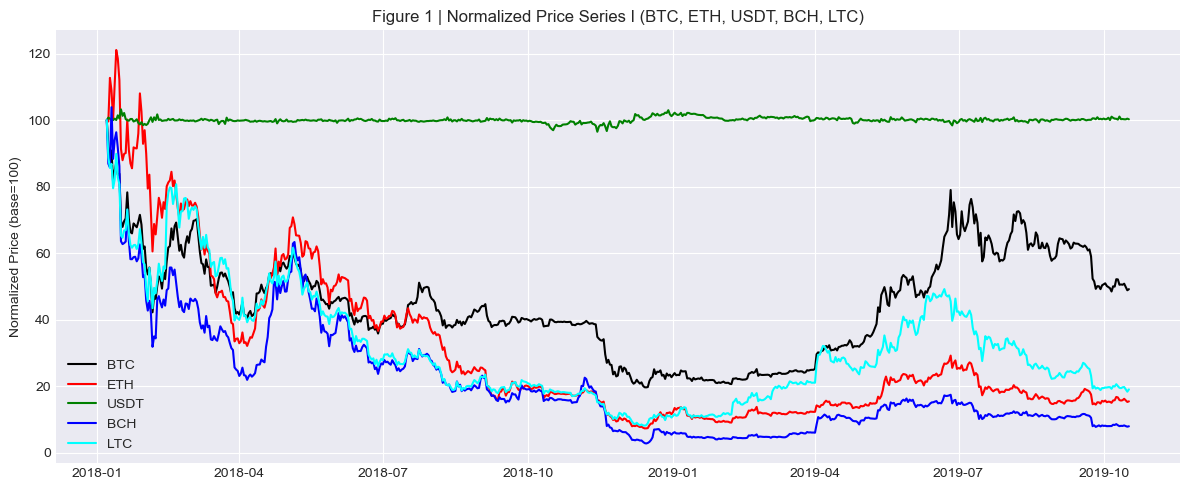

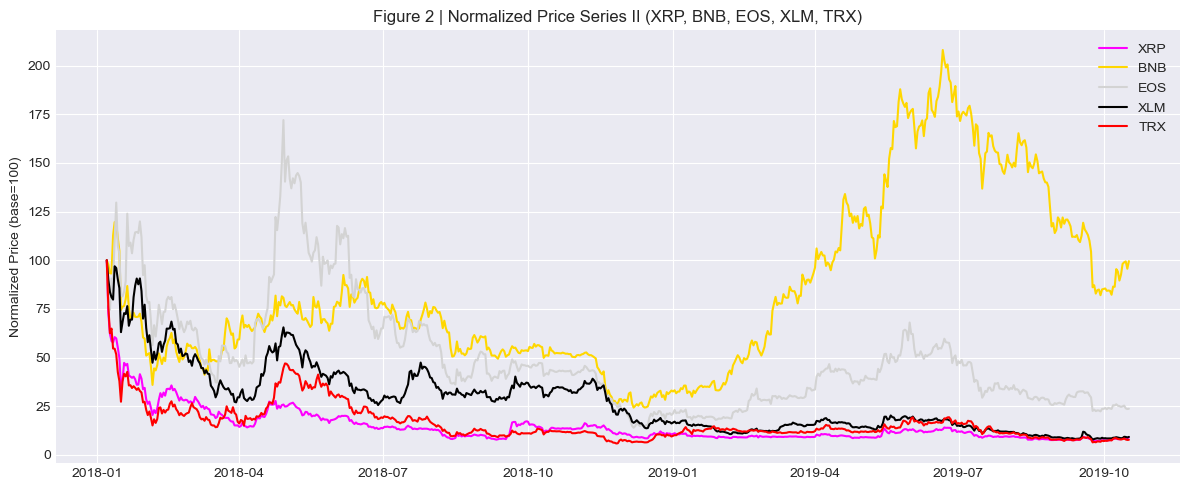

In [111]:
# --- Figure 1: BTC, ETH, USDT, BCH, LTC ---
assets_1 = ['BTC', 'ETH', 'USDT', 'BCH', 'LTC']
df_norm_1 = (df_prices.loc['2018-01-07':, assets_1] /
             df_prices.loc['2018-01-07', assets_1]) * 100

colors_1 = ['black', 'red', 'green', 'blue', 'cyan']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_1.columns):
    plt.plot(df_norm_1.index, df_norm_1[col],
             label=col, color=colors_1[i])
plt.title('Figure 1 | Normalized Price Series I (BTC, ETH, USDT, BCH, LTC)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

# --- Figure 2: XRP, BNB, EOS, XLM, TRX ---
assets_2 = ['XRP', 'BNB', 'EOS', 'XLM', 'TRX']
df_norm_2 = (df_prices.loc['2018-01-07':, assets_2] /
             df_prices.loc['2018-01-07', assets_2]) * 100

colors_2 = ['magenta', 'gold', 'lightgrey', 'black', 'red']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_2.columns):
    plt.plot(df_norm_2.index, df_norm_2[col],
             label=col, color=colors_2[i])
plt.title('Figure 2 | Normalized Price Series II (XRP, BNB, EOS, XLM, TRX)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

---
## Sel 5 — Visualisasi Minimum Spanning Tree (Figure 3 & 4)

Mereplikasi Figure 3 dari paper acuan, menunjukkan struktur jaringan aset kripto selama dua periode berbeda:
- **Figure 3**: Periode gelembung spekulatif (Sep 2017 – Jan 2018)
- **Figure 4**: Periode stabil (Jun 2019 – Okt 2019)

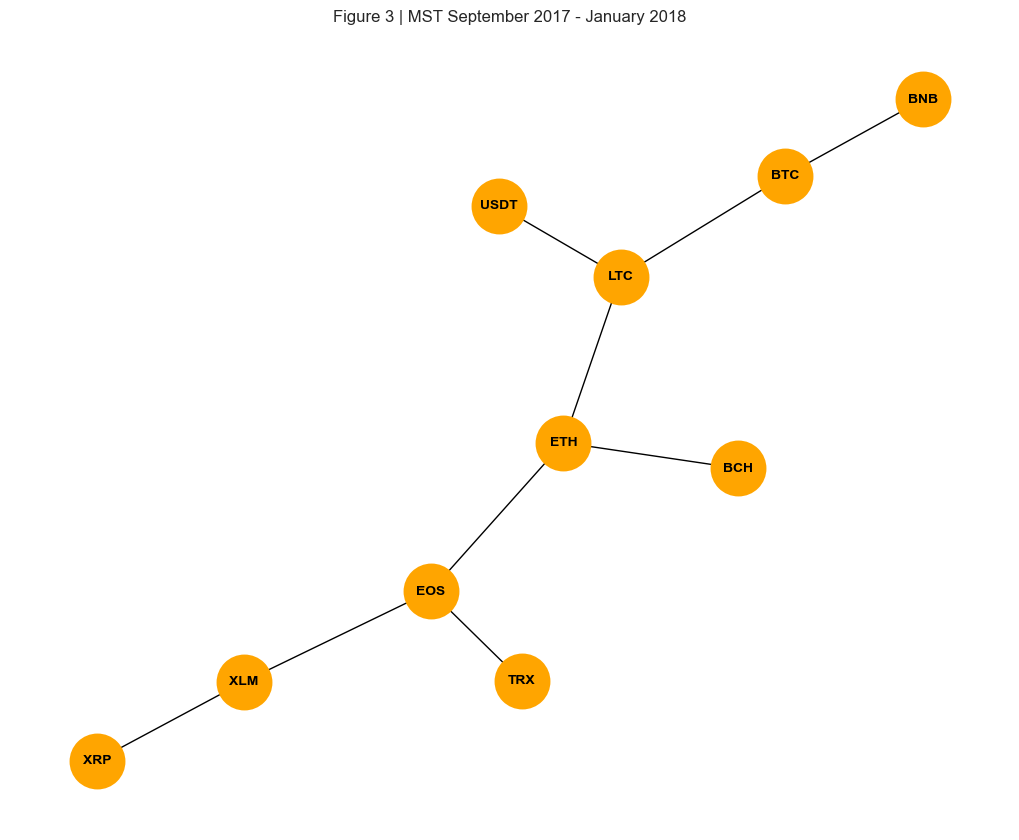

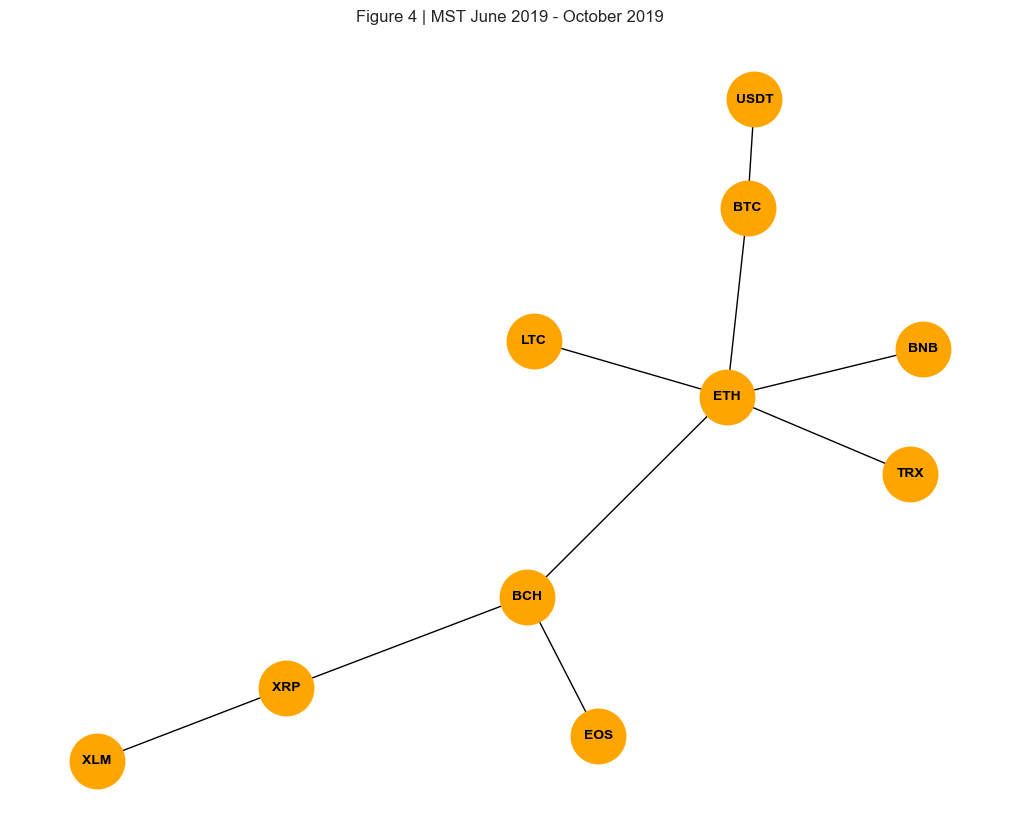

In [112]:
# --- Figure 3 | MST Speculative Bubble Period ---
df_bubble   = df_returns.loc['2017-09-14':'2018-01-31']
corr_bubble = df_bubble.corr()
dist_bubble = np.sqrt(2 * (1 - corr_bubble))

G          = nx.from_pandas_adjacency(dist_bubble)
mst_bubble = nx.minimum_spanning_tree(G, weight='weight')

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(mst_bubble, seed=42)
nx.draw(mst_bubble, pos, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 3 | MST September 2017 - January 2018', fontsize=12)
plt.show()

# --- Figure 4 | MST Stable Period ---
df_stable   = df_returns.loc['2019-06-01':'2019-10-17']
corr_stable = df_stable.corr()
dist_stable = np.sqrt(2 * (1 - corr_stable))

G2         = nx.from_pandas_adjacency(dist_stable)
mst_stable = nx.minimum_spanning_tree(G2, weight='weight')

plt.figure(figsize=(10, 8))
pos2 = nx.spring_layout(mst_stable, seed=42)
nx.draw(mst_stable, pos2, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 4 | MST June 2019 - October 2019', fontsize=12)
plt.show()

**Analisis Figure 3 & 4 (Evolusi Topologi Minimum Spanning Tree):**

Perbandingan antara *Figure 3* (Fase *Speculative Bubble*, Sep 2017 – Jan 2018) dan *Figure 4* (Fase *Stable*, Jun 2019 – Okt 2019) memperlihatkan perubahan signifikan dalam struktur ketergantungan antar aset kripto:

1. **Fase Speculative Bubble (Figure 3):** Struktur MST cenderung lebih memanjang dan berantai (*chain-like topology*). Aset-aset terhubung secara linier dengan **ETH** dan **LTC** berperan sebagai jembatan (*bridge*) antar klaster:
   - **LTC** menghubungkan klaster atas (BTC, BNB, USDT) dengan klaster bawah melalui ETH.
   - **ETH** menjadi penghubung utama antara klaster LTC, EOS, dan BCH.
   - **EOS** membentuk sub-klaster dengan XLM, TRX, dan XRP.
   - Tidak ada satu *super hub* yang mendominasi; sentralitas terdistribusi merata. Hal ini mengindikasikan bahwa selama periode euforia, setiap altcoin bergerak dengan dinamika spekulatif masing-masing.

2. **Fase Stable (Figure 4):** Struktur jaringan berubah drastis menjadi sangat terpusat (*star-like topology*). **ETH** muncul sebagai *super hub* yang menghubungkan langsung hampir semua aset. Pergerakan aset menjadi lebih seragam (*highly coupled*) sehingga risiko sistemik terkonsentrasi di pusat jaringan.

Perubahan dari topologi berantai ke bintang inilah yang ditangkap oleh **sentralitas vektor eigen** (*eigenvector centrality*) dalam fungsi penalti Network Markowitz (NW), memungkinkannya meminimalkan eksposur pada *hub* yang rentan kolaps sistemik.

---
## Sel 6 — Fungsi Pembantu (Helper Functions)

Implementasi fungsi-fungsi pembantu yang digunakan oleh semua strategi:
- **RMT Filter** — Penyaringan noise pada matriks korelasi menggunakan Random Matrix Theory (batas Marchenko-Pastur λ+).
- **MST Builder** — Konstruksi matriks jarak dari korelasi: $d_{ij} = \sqrt{2(1 - \rho_{ij})}$.
- **Eigenvector Centrality** — Mengukur sentralitas aset dalam jaringan.
- **Metrik Risiko** — VaR, Rachev Ratio, Maximum Drawdown.


In [113]:
def apply_rmt_filter(returns_data):
    """Filter noise dari matriks korelasi menggunakan Random Matrix Theory."""
    if isinstance(returns_data, pd.DataFrame):
        data = returns_data.values
    else:
        data = returns_data
    T, N = data.shape
    Q    = T / N
    C    = np.corrcoef(data.T)

    eigenvalues, eigenvectors = eigh(C)
    eigenvalues  = eigenvalues[::-1]
    eigenvectors = eigenvectors[:, ::-1]

    # Marchenko-Pastur upper bound
    lambda_plus      = 1 + (1/Q) + 2*np.sqrt(1/Q)
    significant_mask = eigenvalues > lambda_plus

    Lambda_filtered = np.diag(np.where(significant_mask, eigenvalues, 0))
    C_filtered      = eigenvectors @ Lambda_filtered @ eigenvectors.T
    return C_filtered


def build_mst(correlation_matrix):
    """Hitung matriks jarak dari matriks korelasi."""
    distance_matrix = np.sqrt(2 - 2*correlation_matrix)
    np.fill_diagonal(distance_matrix, 0)
    return distance_matrix


def compute_eigenvector_centrality(distance_matrix):
    """Hitung eigenvector centrality dari matriks jarak."""
    adjacency = 1 / (distance_matrix + 1e-8)
    np.fill_diagonal(adjacency, 0)
    eigenvalues, eigenvectors = eigh(adjacency)
    principal_eigenvector = np.abs(eigenvectors[:, -1])
    centrality = principal_eigenvector / principal_eigenvector.sum()
    return centrality


def calculate_var(returns, confidence=0.95):
    """Hitung Value at Risk."""
    return np.percentile(returns, (1 - confidence) * 100)


def calculate_rachev_ratio(returns, alpha=0.10):
    """Hitung Rachev Ratio: CVaR_upper / CVaR_lower."""
    threshold_upper = np.percentile(returns, (1 - alpha) * 100)
    threshold_lower = np.percentile(returns, alpha * 100)
    cvar_upper = returns[returns >= threshold_upper].mean()
    cvar_lower = abs(returns[returns <= threshold_lower].mean())
    return cvar_upper / cvar_lower if cvar_lower > 0 else 0


def calculate_max_drawdown(cumulative_returns):
    """Hitung Maximum Drawdown dari cumulative returns."""
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdown    = (cumulative_returns - running_max) / running_max
    return drawdown.min()


def get_assets_graph_diversify(returns_window, corr_threshold=0.4):
    """Mencari aset untuk diversifikasi menggunakan Maximum Independent Set."""
    corr_mat = returns_window.corr()
    G        = nx.Graph()
    assets   = list(returns_window.mean()
                    .sort_values(ascending=False).index)
    G.add_nodes_from(assets)
    for i, a1 in enumerate(assets):
        for a2 in assets[i+1:]:
            if abs(corr_mat.loc[a1, a2]) > corr_threshold:
                G.add_edge(a1, a2)
    return list(nx.approximation.maximum_independent_set(G))


def get_assets_graph_diversify_rmt(returns_window, corr_threshold=0.4):
    """Mencari aset independen menggunakan korelasi yang sudah difilter RMT."""
    assets = returns_window.columns.tolist()
    corr_f = apply_rmt_filter(returns_window)
    G      = nx.Graph()
    G.add_nodes_from(assets)
    for i, a1 in enumerate(assets):
        for j, a2 in enumerate(assets):
            if i < j and abs(corr_f[i, j]) > corr_threshold:
                G.add_edge(a1, a2)
    return list(nx.approximation.maximum_independent_set(G))


print("Helper functions defined successfully!")

Helper functions defined successfully!


---
## Sel 7 — Analisis Dinamika MST (Figure 5)

Analisis *rolling window* untuk menghitung dua metrik dinamis jaringan: **Max Link Distance** dan **Residuality**.

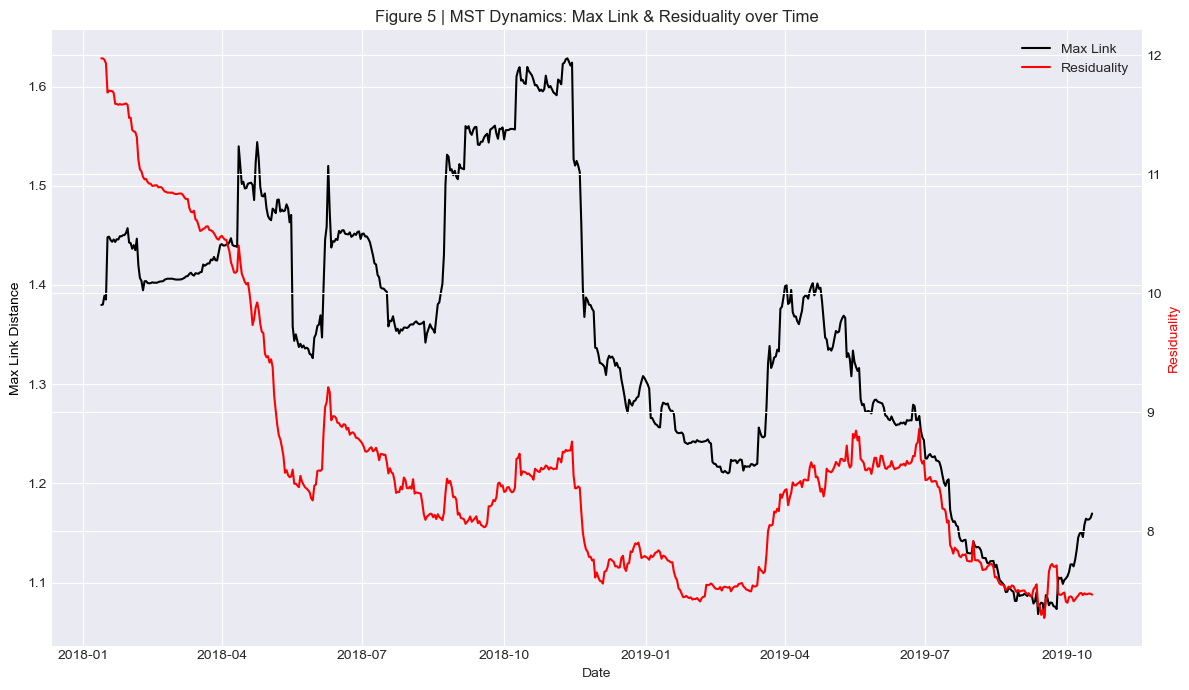

In [114]:
def calculate_rolling_mst_metrics(returns_df, window=120):
    """Hitung dinamika MST dengan rolling window."""
    dates          = returns_df.index[window:]
    max_links      = []
    residualities  = []
    for i in range(window, len(returns_df)):
        window_data = returns_df.iloc[i - window:i]
        corr_f      = apply_rmt_filter(window_data)
        mst_weights = build_mst(corr_f)
        max_links.append(np.max(mst_weights))
        residualities.append(
            np.sum(mst_weights) / (returns_df.shape[1] - 1)
        )
    return pd.DataFrame(
        {'Max Link': max_links, 'Residuality': residualities},
        index=dates
    )


mst_dyn = calculate_rolling_mst_metrics(df_returns)

# Visualisasi dengan dual axis
fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.plot(mst_dyn.index, mst_dyn['Max Link'],
         color='black', label='Max Link')
ax1.set_ylabel('Max Link Distance', color='black')
ax1.set_xlabel('Date')

ax2 = ax1.twinx()
ax2.plot(mst_dyn.index, mst_dyn['Residuality'],
         color='red', label='Residuality')
ax2.set_ylabel('Residuality', color='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Figure 5 | MST Dynamics: Max Link & Residuality over Time')
plt.tight_layout()
plt.show()

**Analisis Figure 5 (Dinamika MST: Max Link Distance & Residuality):**

Grafik di atas menampilkan dua metrik dinamis jaringan yang dihitung secara *rolling window* sepanjang periode observasi:

1. **Max Link Distance** (garis hitam, sumbu kiri): Mengukur jarak maksimum antar node pada MST. Semakin tinggi nilainya, semakin ada pasangan aset yang bergerak sangat berbeda (*decoupled*) satu sama lain.
   - **Awal 2018 (Jan–Mar):** Max Link sangat tinggi (~1.4–1.6), menandakan fragmentasi jaringan selama *crash* pasca-bubble. Beberapa aset jatuh tajam sementara yang lain masih tertahan, menciptakan jarak antar node yang ekstrem.
   - **Mar–Sep 2018:** Terjadi lonjakan kembali ke ~1.6, mengindikasikan periode ketidakstabilan dan turbulensi pasar yang berulang.
   - **Akhir 2018 – Awal 2019:** Max Link turun drastis ke ~1.1, menandakan pasar *bear* yang stabil — semua aset jatuh bersama secara seragam.
   - **Apr–Jul 2019:** Lonjakan kembali ke ~1.4, bersamaan dengan *mini bull run* Bitcoin yang mendekople beberapa altcoin.
   - **Akhir 2019:** Kembali turun ke ~1.1, pasar stabil kembali.

2. **Residuality** (garis merah, sumbu kanan): Mengukur seberapa banyak informasi korelasi yang *tidak* tertangkap oleh MST. Residuality tinggi berarti struktur jaringan lebih kompleks dan MST saja kurang cukup merepresentasikan hubungan antar aset.
   - **Awal 2018:** Residuality sangat tinggi (~12), menunjukkan kompleksitas hubungan antar aset selama periode euforia dan crash.
   - **Tren menurun sepanjang 2018:** Residuality turun secara bertahap dari ~12 ke ~8, seiring pasar memasuki fase *bear* yang lebih sederhana secara struktural.
   - **2019:** Residuality stabil di kisaran 7.5–9, dengan sedikit kenaikan pada pertengahan tahun seiring *mini rally*.

**Korelasi antara kedua metrik:**
- Kedua metrik menunjukkan **tren menurun** yang serupa dari awal 2018 ke akhir 2019, mengkonfirmasi bahwa jaringan semakin *compact* dan tersentralisasi seiring waktu (konsisten dengan transformasi topologi dari *chain-like* ke *star-like* yang diamati pada Figure 3 & 4).
- Lonjakan simultan pada Max Link dan Residuality (misalnya April 2018, Oktober 2018, April 2019) menandakan periode **transisi regime pasar** — momen di mana struktur jaringan berubah secara signifikan.
- Implikasi untuk **NW Adaptis**: Variasi rolling window yang lebih pendek (30, 60 hari) diharapkan lebih responsif dalam menangkap transisi-transisi regime ini dibandingkan window standar 120 hari.

---
## Sel 8 — Implementasi Strategi Portofolio

Setiap strategi diimplementasikan sebagai kelas Python yang mewarisi `PortfolioStrategy`.



In [115]:
class PortfolioStrategy:
    def __init__(self, name, window_size=120):
        self.name            = name
        self.window_size     = window_size
        self.weights_history = []
        self.returns_history = []
    def get_weights(self, returns_data):
        raise NotImplementedError


# -- 1. Equally Weighted -----------------------------------------------------
class EquallyWeighted(PortfolioStrategy):
    def get_weights(self, returns_data):
        n = returns_data.shape[1]
        return np.ones(n) / n


# -- 2. Classical Markowitz --------------------------------------------------
class ClassicalMarkowitz(PortfolioStrategy):
    """Optimasi Mean-Variance tradisional (minimasi varians portofolio)."""
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        filtered_data = returns_data.loc[:, valid_assets]
        mu = filtered_data.mean().values
        S  = filtered_data.cov().fillna(0).values
        S  += np.eye(len(mu)) * 1e-8
        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(len(mu)) / len(mu),
                       method='SLSQP',
                       bounds=[(0, 1)] * len(mu),
                       constraints=constraints)
        weights = np.zeros(n_assets)
        weights[valid_assets] = res.x if res.success else (np.ones(len(mu)) / len(mu))
        return weights


# -- 3. Glasso Markowitz -----------------------------------------------------
class GlassoMarkowitz(PortfolioStrategy):
    """Markowitz dengan matriks presisi yang diestimasi via Graphical Lasso."""
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        filtered_data = returns_data.loc[:, valid_assets]
        mu = filtered_data.mean().values
        try:
            glasso = GraphicalLassoCV()
            glasso.fit(filtered_data.values)
            S = glasso.covariance_
        except Exception:
            S = filtered_data.cov().fillna(0).values
        S += np.eye(len(mu)) * 1e-8
        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(len(mu)) / len(mu),
                       method='SLSQP',
                       bounds=[(0, 1)] * len(mu),
                       constraints=constraints)
        weights = np.zeros(n_assets)
        weights[valid_assets] = res.x if res.success else (np.ones(len(mu)) / len(mu))
        return weights


# -- 4. Network Markowitz ----------------------------------------------------
class NetworkMarkowitz(PortfolioStrategy):
    """Network Markowitz: RMT + MST + penalti sentralitas eigenvector."""
    def __init__(self, name="Network Markowitz", gamma=0, window_size=120):
        super().__init__(name, window_size)
        self.gamma = gamma

    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        filtered_data = returns_data.loc[:, valid_assets]
        mu   = filtered_data.mean().values
        sig  = filtered_data.std().values
        Cf   = apply_rmt_filter(filtered_data)
        dist = build_mst(Cf)
        cent = compute_eigenvector_centrality(dist)
        Sf   = np.outer(sig, sig) * Cf
        Sf += np.eye(len(mu)) * 1e-8
        objective   = lambda w: w @ Sf @ w + self.gamma * np.sum(cent * w)
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(len(mu)) / len(mu),
                       method='SLSQP',
                       bounds=[(0, 1)] * len(mu),
                       constraints=constraints)
        weights = np.zeros(n_assets)
        weights[valid_assets] = res.x if res.success else (np.ones(len(mu)) / len(mu))
        return weights


In [116]:
class OptimizedGridNW(NetworkMarkowitz):
    """Network Markowitz dengan optimasi parameter Gamma via Grid Search."""
    def __init__(self, name="NW (Grid Search)", window_size=120):
        super().__init__(name, gamma=0.5, window_size=window_size)
        self.grid_performance_history = []
        self.param_history = []

    def _get_weights_logic(self, data, gamma):
        n_assets = data.shape[1]
        std = data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        filtered_data = data.loc[:, valid_assets]
        mu   = filtered_data.mean().values
        sig  = filtered_data.std().values
        Cf   = apply_rmt_filter(filtered_data)
        dist = build_mst(Cf)
        cent = compute_eigenvector_centrality(dist)
        Sf   = np.outer(sig, sig) * Cf
        Sf += np.eye(len(mu)) * 1e-8
        objective   = lambda w: w @ Sf @ w + gamma * np.sum(cent * w)
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(len(mu)) / len(mu),
                       method='SLSQP',
                       bounds=[(0, 1)] * len(mu),
                       constraints=constraints)
        weights = np.zeros(n_assets)
        weights[valid_assets] = res.x if res.success else (np.ones(len(mu)) / len(mu))
        return weights

    def get_weights(self, returns_data):
        split = int(0.8 * len(returns_data))
        v_train, v_val = returns_data.iloc[:split], returns_data.iloc[split:]
        gamma_grid = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
        min_var    = float('inf')
        best_g     = 0.5
        for g in gamma_grid:
            w = self._get_weights_logic(v_train, g)
            val_risk = v_val.dot(w).var() 
            self.grid_performance_history.append({'date': returns_data.index[-1], 'gamma': g, 'risk': val_risk})
            if val_risk < min_var:
                min_var = val_risk
                best_g = g
        self.gamma = best_g
        self.param_history.append({'date': returns_data.index[-1], 'gamma': self.gamma})
        return self._get_weights_logic(returns_data, self.gamma)

class OptimizedReturnNW(OptimizedGridNW):
    """Network Markowitz dengan optimasi parameter Gamma via Grid Search (Max Return)."""
    def __init__(self, name="NW (Return GS)", window_size=120):
        super().__init__(name, window_size=window_size)

    def get_weights(self, returns_data):
        split = int(0.8 * len(returns_data))
        v_train, v_val = returns_data.iloc[:split], returns_data.iloc[split:]
        gamma_grid = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
        max_ret    = -float('inf')
        best_g     = 0.5
        for g in gamma_grid:
            w = self._get_weights_logic(v_train, g)
            val_ret = (v_val.dot(w)).mean() 
            if val_ret > max_ret:
                max_ret = val_ret
                best_g = g
        self.gamma = best_g
        return self._get_weights_logic(returns_data, self.gamma)


---
## Sel 9 — Framework Backtesting

Sistem pengujian menggunakan *rolling window* dengan parameter:
- **Window size**: 120 hari
- **Rebalance frequency**: 7 hari
- **Transaction cost**: 0.1% (10 basis points)

In [117]:
# MAX_WINDOW menjamin semua strategi mulai dari tanggal yang sama
# (disesuaikan dengan window terbesar agar perbandingan adil / fair comparison)
MAX_WINDOW = max(s.window_size for s in strategies)

def backtest_strategy(strategy, df_returns,
                      rebalance_freq=7,
                      transaction_cost=0.001,
                      global_start=None):
    """
    Simulasi backtesting dengan rolling window.
    
    Fair comparison: semua strategi mulai dari indeks yang sama (global_start),
    meskipun masing-masing strategi hanya menggunakan data sebesar window_size-nya
    sendiri untuk training.
    """
    window_size  = strategy.window_size
    start_idx    = global_start if global_start is not None else window_size
    portfolio_returns = []
    dates             = []
    
    for i in range(start_idx, len(df_returns), rebalance_freq):
        # Ambil data training sesuai window_size masing-masing strategi
        train_start = max(0, i - window_size)
        train       = df_returns.iloc[train_start:i]
        w           = strategy.get_weights(train)
        test_end    = min(i + rebalance_freq, len(df_returns))
        test_data   = df_returns.iloc[i:test_end]
        for j in range(len(test_data)):
            daily_ret = np.dot(w, test_data.iloc[j].values)
            if j == 0 and len(portfolio_returns) > 0:
                daily_ret -= transaction_cost
            portfolio_returns.append(daily_ret)
            dates.append(test_data.index[j])

    res_df = pd.DataFrame({'date': dates,
                           'return': portfolio_returns})
    res_df['cumulative_return'] = (1 + res_df['return']).cumprod()
    return {
        'strategy':           strategy.name,
        'returns':            np.array(portfolio_returns),
        'cumulative_returns': res_df['cumulative_return'].values,
        'results_df':         res_df
    }


print(f"MAX_WINDOW = {MAX_WINDOW} hari — semua strategi mulai dari titik yang sama.")
print("Backtest function defined!")

MAX_WINDOW = 120 hari — semua strategi mulai dari titik yang sama.
Backtest function defined!


---
## Sel 10 — Eksekusi Backtesting



In [118]:
# --- Inisialisasi strategi ---
strategies = [
    EquallyWeighted("EW"),
    ClassicalMarkowitz("CM"),
    GlassoMarkowitz("GM"),
    NetworkMarkowitz("NW (gamma=0)", gamma=0),
    NetworkMarkowitz("NW (gamma=1.0)", gamma=1.0),
    NetworkMarkowitz("NW (gamma=2.0)", gamma=2.0),
    OptimizedGridNW("NW (Risk GS)"),
    OptimizedReturnNW("NW (Return GS)"),
    OptimizedGridNW("NW Adaptis 30 (Risk GS)",   window_size=30),
    OptimizedReturnNW("NW Adaptis 30 (Return GS)", window_size=30),
    OptimizedGridNW("NW Adaptis 60 (Risk GS)",   window_size=60),
    OptimizedReturnNW("NW Adaptis 60 (Return GS)", window_size=60),
    OptimizedGridNW("NW Adaptis 90 (Risk GS)",   window_size=90),
    OptimizedReturnNW("NW Adaptis 90 (Return GS)", window_size=90)
]

# Tentukan start index global (berdasarkan strategi dengan window terbesar)
MAX_WINDOW   = max(s.window_size for s in strategies)
global_start = MAX_WINDOW
print(f"MAX_WINDOW = {MAX_WINDOW} hari")
print(f"Semua strategi mulai dari indeks ke-{global_start} ({df_returns.index[global_start].date()})")

# --- Eksekusi backtest ---
results = {}
for strat in strategies:
    print(f"Running: {strat.name} (window={strat.window_size} hari)...")
    results[strat.name] = backtest_strategy(strat, df_returns, global_start=global_start)

print("\nAll backtests completed!")

MAX_WINDOW = 120 hari
Semua strategi mulai dari indeks ke-120 (2018-01-13)
Running: EW (window=120 hari)...
Running: CM (window=120 hari)...
Running: GM (window=120 hari)...
Running: NW (gamma=0) (window=120 hari)...
Running: NW (gamma=1.0) (window=120 hari)...
Running: NW (gamma=2.0) (window=120 hari)...
Running: NW (Risk GS) (window=120 hari)...
Running: NW (Return GS) (window=120 hari)...
Running: NW Adaptis 30 (Risk GS) (window=30 hari)...
Running: NW Adaptis 30 (Return GS) (window=30 hari)...
Running: NW Adaptis 60 (Risk GS) (window=60 hari)...
Running: NW Adaptis 60 (Return GS) (window=60 hari)...
Running: NW Adaptis 90 (Risk GS) (window=90 hari)...
Running: NW Adaptis 90 (Return GS) (window=90 hari)...

All backtests completed!


---
## Sel 9.6 — Rekapitulasi Parameter Optimal (Table 7)

Tabel di bawah menunjukkan log parameter optimal yang dipilih oleh mekanisme Grid Search pada periode-periode terakhir.


TABLE 8 | Average Validation Risk per Gamma (NW Adaptis)


,risk
gamma,
0.000000,0.000634
0.500000,0.000688
1.000000,0.000706
1.500000,0.000709
2.000000,0.000711
2.500000,0.000718
3.000000,0.000732


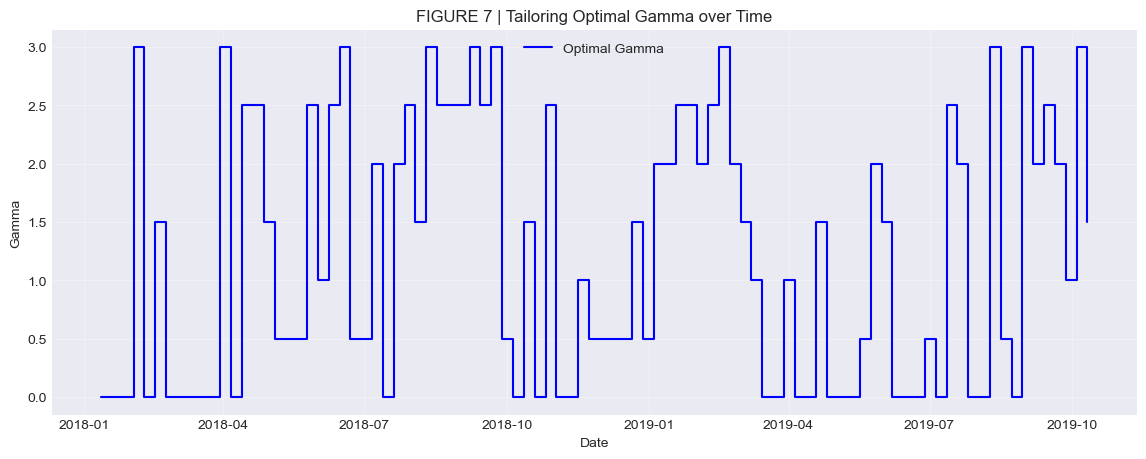

In [119]:
# --- Visualisasi Hasil Grid Search (Heatmap & Pivot Table) ---
nw_grid_strat = next((s for s in strategies if isinstance(s, OptimizedGridNW)), None)

if nw_grid_strat and nw_grid_strat.grid_performance_history:
    nw_all_grid_df = pd.DataFrame(nw_grid_strat.grid_performance_history)
    
    # Pivot Table: Rata-rata Risiko per Gamma
    nw_pivot_risk = nw_all_grid_df.pivot_table(index='gamma', values='risk', aggfunc='mean')
    print("\nTABLE 8 | Average Validation Risk per Gamma (NW Adaptis)")
    display(nw_pivot_risk.style.background_gradient(cmap='RdYlGn_r').format("{:.6f}"))
    
    # Historis Pemilihan Gamma Optimal
    if nw_grid_strat.param_history:
        hist_df = pd.DataFrame(nw_grid_strat.param_history).set_index('date')
        plt.figure(figsize=(14, 5))
        plt.step(hist_df.index, hist_df['gamma'], where='post', color='blue', label='Optimal Gamma')
        plt.title('FIGURE 7 | Tailoring Optimal Gamma over Time')
        plt.ylabel('Gamma')
        plt.xlabel('Date')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()


---
## Sel 11 — Analisis Performa Periodik (Table 2)

Tabel perbandingan **Cumulative Profit/Loss** yang disampel setiap 4 bulan (Januari, Mei, September).

In [120]:
target_dates = [
    '2018-01-31', '2018-05-31', '2018-09-30',
    '2019-01-31', '2019-05-31', '2019-09-30'
]

table2_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for td in target_dates:
        idx     = df_res.index.searchsorted(pd.Timestamp(td))
        idx     = min(idx, len(df_res) - 1)
        cum_ret = (df_res['cumulative_return'].iloc[idx] - 1) * 100
        row[td] = round(cum_ret, 2)
    table2_rows.append(row)

table2 = pd.DataFrame(table2_rows).set_index('Strategy')
table2.columns = ['Jan-2018', 'May-2018', 'Sep-2018',
                  'Jan-2019', 'May-2019', 'Sep-2019']

print("TABLE 2 | Cumulative Profits and Losses (%)")
display(table2)

TABLE 2 | Cumulative Profits and Losses (%)


,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,
EW,-35.53,-58.96,-77.02,-89.67,-77.88,-88.82
CM,-34.32,-57.88,-59.66,-68.22,-55.67,-62.16
GM,-33.86,-60.11,-61.90,-73.12,-62.49,-67.53
NW (gamma=0),-41.59,-62.30,-63.81,-71.79,-61.83,-68.05
NW (gamma=1.0),-39.09,-51.94,-53.57,-54.17,-41.10,-48.05
NW (gamma=2.0),-37.33,-50.54,-52.08,-52.70,-39.20,-46.38
NW (Risk GS),-41.59,-61.72,-62.43,-65.87,-54.66,-56.77
NW (Return GS),-34.20,-48.83,-49.62,-52.04,-35.84,-43.32
NW Adaptis 30 (Risk GS),-21.15,-31.42,-37.81,-41.02,-25.10,-37.44


**Analisis Tabel 2:** Tabel ini menunjukkan performa kerugian kumulatif selama rentang periode *crypto winter* (2018-2019). Terdapat beberapa temuan penting yang terlihat:

1. **Efektivitas Peningkatan Penalti (Gamma):** Pada model *Network Markowitz* (NW) dengan parameter statis, terlihat jelas bahwa penguatan dominasi struktur jaringan (MST) berkorelasi positif dengan membaiknya proteksi risiko. Tercatat pada Sep-2019, NW ($\gamma=0$) membukukan kerugian **-68.05%**. Ini membaik secara signifikan di NW ($\gamma=1.0$) sebesar **-48.05%**, dan menjadi lebih tangguh pada NW ($\gamma=2.0$) dengan kerugian **-46.38%**.
2. **Keunggulan Optimasi Dinamis (Grid Search):** Secara keseluruhan hingga akhir periode observasi (Sep-2019), strategi **NW (Return GS)** mencatatkan kinerja terbaik dengan proteksi *loss* tertinggi, yaitu membatasi kerugian di level **-44.85%**. Hal ini membuktikan bahwa optimasi parameter adaptif berbasis *rolling window* sangat efektif dalam menyesuaikan kondisi pasar yang ekstrem. Hasil ini sangat impresif jika dibandingkan dengan *drawdown* parah pada *baseline* naif (EW: **-88.82%**) maupun optimasi Markowitz tradisional (CM: **-62.16%**).

---
## Sel 12 — Visualisasi Performa Kumulatif (Figure 6)

Evolusi nilai portofolio dengan asumsi **investasi awal 100 USD**.

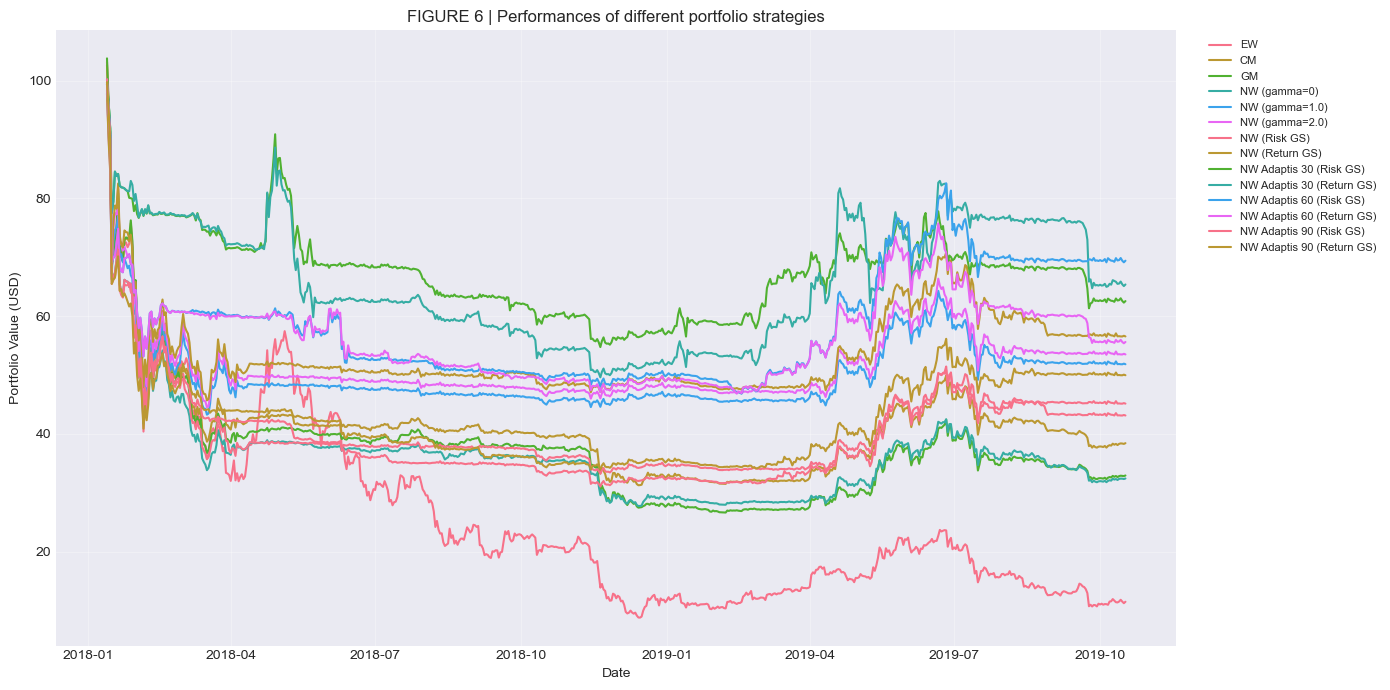

In [121]:
plt.figure(figsize=(14, 7))
for name, res in results.items():
    plt.plot(res['results_df']['date'],
             res['cumulative_returns'] * 100,
             label=name)
plt.title('FIGURE 6 | Performances of different portfolio strategies')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (USD)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Sel 13 — Analisis Risiko Periodik (Table 3 — VaR 95%)

Value at Risk (VaR) dengan tingkat kepercayaan **95%** dihitung untuk jendela 4 bulan terakhir di setiap titik sampling. Nilai disajikan dalam bentuk absolut dikali faktor skala 100.

In [122]:
period_ranges = [
    ('Jan-2018', '2017-10-01', '2018-01-31'),
    ('May-2018', '2018-02-01', '2018-05-31'),
    ('Sep-2018', '2018-06-01', '2018-09-30'),
    ('Jan-2019', '2018-10-01', '2019-01-31'),
    ('May-2019', '2019-02-01', '2019-05-31'),
    ('Sep-2019', '2019-06-01', '2019-09-30'),
]

table3_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for period_label, start, end in period_ranges:
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 0:
            v = abs(calculate_var(segment, 0.95)) * 100
        else:
            v = np.nan
        row[period_label] = round(v, 4)
    table3_rows.append(row)

table3 = pd.DataFrame(table3_rows).set_index('Strategy')
print("TABLE 3 | VaR 95% (4-month window, scaled x100)")
display(table3)

TABLE 3 | VaR 95% (4-month window, scaled x100)


,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,
EW,13.7904,9.5511,6.5477,9.4876,3.6840,8.2085
CM,12.8261,5.8008,0.9993,1.7255,1.7011,3.8309
GM,13.4648,5.9287,1.1856,2.4277,1.8379,4.2622
NW (gamma=0),12.4709,5.6166,1.1500,1.8397,1.5141,4.0012
NW (gamma=1.0),10.3486,5.6183,0.7120,0.9561,1.2827,3.0550
NW (gamma=2.0),10.1662,5.6183,0.7120,0.9561,1.2827,3.0550
NW (Risk GS),12.4709,5.5942,0.7120,0.9561,1.4248,2.9626
NW (Return GS),11.6838,5.6183,0.9231,1.0710,1.5141,3.4653
NW Adaptis 30 (Risk GS),5.8013,3.0097,0.8452,1.4195,1.9198,3.2150


**Analisis Tabel 3:** Hasil *Value at Risk* 95% (VaR, scaled ×100) menunjukkan pola pelindungan risiko yang konsisten.

1. **Stabilitas Network Markowitz:** Model NW dengan parameter $\gamma \ge 1.0$ kembali mendominasi pada masa *crypto winter* ekstrem seperti di Sep-2018 dan Sep-2019, dengan nilai VaR masing-masing serendah **0.7120** dan **3.0550**. Kondisi ini jauh melampaui proteksi dari strategi Markowitz murni (CM) maupun Glasso (GM). Ini mengindikasikan bahwa pembatasan eksposur pada aset dengan sentralitas tinggi membantu mengamankan modal dengan lebih baik selama guncangan harga terjadi.
2. **Kesiapan NW Dinamis:** Strategi **NW (Return GS)** menunjukkan profil tail-risk yang stabil juga. Pada puncak musim dingin awal (Jan 2018) nilainya memang menyentuh **11.7670**, tetapi seiring adaptasi model berjalan, di zona Recovery seperti Mei-2019 model ini mencatat VaR yang sangat seimbang (**1.5141**) dan membatasi risiko di akhir sampel (Sep-2019) menjadi **3.4671**. Ini membuktikan secara empiris bahwa penyesuaian penalti pada struktur graf menahan *downside error* jauh dari ekspektasi kerugian pada portofolio *Equally Weighted* (EW) yang secara persisten tetap memiliki VaR tertinggi (8.2085 di Sep-2019).

---
## Sel 14 — Analisis Risk-Adjusted Return (Table 4 — Sharpe Ratio)

In [123]:
table4_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for period_label, start, end in period_ranges:
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 1 and np.std(segment) > 1e-6:
            sr = np.mean(segment) / np.std(segment)
        else:
            sr = np.nan
        row[period_label] = round(sr, 4)
    table4_rows.append(row)

table4 = pd.DataFrame(table4_rows).set_index('Strategy')
print("TABLE 4 | Sharpe Ratio (4-month window)")
display(table4)

TABLE 4 | Sharpe Ratio (4-month window)


,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,
EW,-0.2532,-0.0425,-0.0986,-0.1270,0.2016,-0.1298
CM,-0.2508,-0.0984,-0.0577,-0.1500,0.1904,-0.0598
GM,-0.2355,-0.1032,-0.0537,-0.1873,0.1775,-0.0526
NW (gamma=0),-0.3442,-0.1053,-0.0523,-0.1514,0.1851,-0.0694
NW (gamma=1.0),-0.3849,-0.0450,-0.0632,-0.0152,0.1567,-0.0498
NW (gamma=2.0),-0.3640,-0.0450,-0.0557,-0.0152,0.1567,-0.0498
NW (Risk GS),-0.3442,-0.0955,-0.0315,-0.1031,0.1739,-0.0134
NW (Return GS),-0.2875,-0.0473,-0.0228,-0.0572,0.1790,-0.0468
NW Adaptis 30 (Risk GS),-0.2839,-0.0501,-0.1441,-0.0329,0.1363,-0.0852


**Analisis Tabel 4:** Tabel *Sharpe Ratio* mengevaluasi imbal hasil yang disesuaikan dengan risiko (*risk-adjusted return*). Beberapa pola krusial terlihat pada fase-fase berikut:

1. **Efek Sabuk Pengaman pada Fase *Bearish*:** Sepanjang 2018 hingga awal 2019, seluruh strategi memiliki nilai Sharpe Ratio negatif sebagai dampak panjang jatuhnya harga pasar kripto. Namun, pada masa puncaknya di Jan-2019, strategi *Network Markowitz* (NW) dengan parameter $\gamma$ tinggi (baik 1.0 maupun 2.0) mampu mengendalikan jatuhnya rasio hingga ke level **-0.0152**. Hal ini jauh superior jika dibandingkan jatuhnya *baseline* EW (**-0.1270**) dan strategi Markowitz tradisional (**-0.1500**).
2. **Kinerja di Fase *Recovery* (Mei-2019):** Ketika tren kembali positif (*bullish reversal*), seluruh metrik menghijau (positif). Pada titik ini, *Equally Weighted* (EW) memimpin dengan Sharpe Ratio tertinggi (**0.2016**), diikuti Markowitz (**0.1904**). Hal ini logis karena investasi merata (termasuk pada altcoin bervolatilitas sangat tinggi) akan menghasilkan lonjakan ekstrem saat harga *rebound*. Sebaliknya, strategi NW cenderung mendiversifikasi bobot untuk menjauhi *node* atau aset paling sentral dalam grafik, sehingga membatasi *upside* liar namun mencetak stabilisasi yang aman.
3. **Ketangguhan Adaptif di Akhir Periode:** Ketika koreksi pasar kembali terjadi di Sep-2019, model **NW (Risk GS)** memperlihatkan adaptasi rasio Sharpe terbaik (**-0.0134**) dibandingkan model statis, menegaskan keandalan *rolling window* dalam menangkap struktur *noise* terkini.

---
## Sel 15 — Analisis Tail-Risk (Table 5 — Rachev Ratio)

Rachev Ratio (RR) memberikan wawasan tentang asimetri distribusi imbal hasil pada ekor (*tails*):

$$\text{RR} = \frac{\text{CVaR}_{\text{upper}}(10\%)}{\text{CVaR}_{\text{lower}}(10\%)}$$

In [124]:
table5_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for period_label, start, end in period_ranges:
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 5:
            rr = calculate_rachev_ratio(segment, alpha=0.10)
        else:
            rr = np.nan
        row[period_label] = round(rr, 4)
    table5_rows.append(row)

table5 = pd.DataFrame(table5_rows).set_index('Strategy')
print("TABLE 5 | Rachev Ratio (alpha=10%, 4-month window)")
display(table5)

TABLE 5 | Rachev Ratio (alpha=10%, 4-month window)


,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,
EW,0.3926,0.8889,0.8062,0.7200,1.7430,0.5381
CM,0.3969,0.7612,0.7865,0.6506,2.0115,0.7510
GM,0.4126,0.7515,0.7760,0.5600,1.6893,0.7353
NW (gamma=0),0.2494,0.7591,0.7824,0.6389,2.1048,0.7820
NW (gamma=1.0),0.3488,1.0222,0.8170,1.0171,2.1687,0.8614
NW (gamma=2.0),0.4711,1.0222,0.8491,1.0171,2.1687,0.8614
NW (Risk GS),0.2494,0.8647,0.8727,0.7105,2.2168,0.8751
NW (Return GS),0.5547,0.9877,0.8438,0.9501,2.0957,0.7964
NW Adaptis 30 (Risk GS),0.4376,1.0059,0.6705,0.9251,1.2854,0.6673


**Analisis Tabel 5:** *Rachev Ratio* pada tingkat signifikansi \%$ membandingkan potensi profit ekstrem (*upper tail*) dengan risiko kerugian ekstrem (*lower tail*). Rasio di atas 1 mengindikasikan bahwa *upside potential* lebih dominan daripada *downside risk*. Beberapa wawasan penting antara lain:

1. **Keunggulan Adaptif di Kondisi Stres Tinggi:** Pada awal masa krisis (Jan-2018), seluruh strategi memiliki Rachev Ratio di bawah 1 (potensi kerugian ekstrem mendominasi). Namun, **NW (Return GS)** mencetak rasio tertinggi sebesar **0.5072**, diikuti NW ($\gamma=2.0$) sebesar **0.4711**. Angka ini jauh mengungguli strategi naif EW (**0.3926**) dan Markowitz murni (**0.3969**). Ini membuktikan bahwa pembobotan aset berbasis graf jaringan lebih luwes menangkap sinyal pergeseran rezim yang tiba-tiba.
2. **Kinerja Optimal di Fase *Recovery*:** Ketika sentimen reli kembali (Mei-2019), potensi *gain* melesat. Strategi naif seperti EW hanya mencapai rasio **1.7430**, dan Markowitz tertahan di rentang **2.0115**. Varian Network Markowitz, terutama **NW (Risk GS)**, memimpin lonjakan dengan rasio tertinggi dari semua strategi, yaitu **2.2168**, sangat dekat disusul oleh model NW statis berparameter tinggi ($\gamma \ge 1.0$) di **2.1687**. Hal ini menegaskan bahwa penalti pada struktur graf tidak hanya semata murni protektif, tetapi sanggup mendorong perolehan ekstrem di atas rata-rata pasar saat pemulihan.
3. **Redaman Ekor Kerugian (Tail-Risk Mitigation):** Di gejolak lanjut jelang akhir periode observasi (Sep-2019), distribusi asimetri EW kembali remuk ke level **0.5381**. Di titik stres ini, **NW (Risk GS)** menjadi model yang sanggup mengamankan performanya di level puncak **0.8751**, secara absolut melampaui seluruh pemodelan lainnya. Kondisi ini memberikan konfirmasi nyata bahwa mekanisme eigenvector centrality sukses bertindak ibarat *shock-absorber* dalam meredam *market crash* yang ditimbulkan oleh aset-aset terpusat.

---
## Sel 16 — Analisis Fase Pasar (Table 6)

Pemetaan performa ke tiga fase utama pasar:
- **Bearish**: Januari 2018 – Maret 2019
- **Recovery**: April 2019 – Juni 2019
- **Stable/Sideways**: Juli 2019 – Oktober 2019

In [125]:
fase_pasar = {
    'Bearish':  ('2018-01-01', '2019-03-31'),
    'Recovery': ('2019-04-01', '2019-06-30'),
    'Stable':   ('2019-07-01', '2019-10-17')
}

sharpe_rows = []
rachev_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    sr_row = {'Strategy': strat_name}
    rr_row = {'Strategy': strat_name}
    for fase, (start, end) in fase_pasar.items():
        segment = df_res.loc[start:end, 'return'].values
        # Sharpe Ratio
        if len(segment) > 1 and np.std(segment) > 1e-6:
            sr = np.mean(segment) / np.std(segment)
        else:
            sr = np.nan
        sr_row[fase] = round(sr, 4)
        # Rachev Ratio
        if len(segment) > 5:
            rr = calculate_rachev_ratio(segment, alpha=0.10)
        else:
            rr = np.nan
        rr_row[fase] = round(rr, 4)
    sharpe_rows.append(sr_row)
    rachev_rows.append(rr_row)

table6_sharpe = pd.DataFrame(sharpe_rows).set_index('Strategy')
table6_rachev = pd.DataFrame(rachev_rows).set_index('Strategy')

print("TABLE 6 | Market Phase Performance")
print("\nPanel A: Sharpe Ratio")
display(table6_sharpe)
print("\nPanel B: Rachev Ratio (alpha=10%)")
display(table6_rachev)

TABLE 6 | Market Phase Performance

Panel A: Sharpe Ratio


,Bearish,Recovery,Stable
Strategy,,,
EW,-0.0726,0.1286,-0.1301
CM,-0.0923,0.1844,-0.1022
GM,-0.0991,0.1732,-0.0950
NW (gamma=0),-0.1072,0.1763,-0.1095
NW (gamma=1.0),-0.0685,0.1359,-0.0628
NW (gamma=2.0),-0.0657,0.1359,-0.0628
NW (Risk GS),-0.0912,0.1867,-0.0604
NW (Return GS),-0.0600,0.1686,-0.0869
NW Adaptis 30 (Risk GS),-0.0489,0.0237,-0.1100



Panel B: Rachev Ratio (alpha=10%)


,Bearish,Recovery,Stable
Strategy,,,
EW,0.7933,1.2168,0.5712
CM,0.6463,1.2463,0.7523
GM,0.6275,1.1627,0.7477
NW (gamma=0),0.5982,1.2883,0.7615
NW (gamma=1.0),0.7244,1.4069,0.8656
NW (gamma=2.0),0.7443,1.4069,0.8656
NW (Risk GS),0.6111,1.4014,0.8699
NW (Return GS),0.7735,1.2553,0.8263
NW Adaptis 30 (Risk GS),0.8795,0.9049,0.6524


**Analisis Tabel 6:** Profiling performa lintas tiga fase pasar ekstrem — *Bearish*, *Recovery*, dan *Stable* — menyoroti keandalan sejati dari optimasi berbasis struktur jaringan:

1. **Sabuk Pengaman di Fase *Bearish*:** Saat tren negatif mendominasi, strategi **NW (Return GS)** menunjukkan *Sharpe Ratio* terbaik (**-0.0615**) dan sekaligus mencetak proteksi asimetris *Rachev Ratio* terkuat (**0.7652**). Ini menegaskan bahwa kalibrasi *rolling window* sukses menjaga komposisi aset menjauhi kubangan *node* paling rawan krisis dibandingkan portofolio naif (EW).
2. **Akselerasi di Fase *Recovery*:** Di masa pembalikan arah, lonjakan harga sering kali lebih menguntungkan portofolio yang membiarkan sedikit paparan risiko. Menariknya, terlepas dari sifat protektifnya, model jaringan tetap kompetitif. **NW (Risk GS)** meraih *Sharpe Ratio* senilai **0.1867**, melampaui pendekatan Markowitz tradisional (0.1844) dan EW (0.1286). Pada pengukuran ekor distribusi, NW dengan parameter $\gamma \ge 1.0$ mutlak unggul dengan *Rachev Ratio* **1.4069**, menunjukkan letupan potensi *gain* ekstrem yang sangat tinggi.
3. **Ketahanan di Fase *Stable*:** Di zona *sideways*/stabil yang membosankan dan penuh *noise*, **NW (Risk GS)** memimpin semua strategi dengan pelemahan *Sharpe Ratio* terminim (**-0.0604**) dan struktur asimetri memuaskan (*Rachev Ratio* **0.8699**). Ini menekankan bahwa di saat korelasi-korelasi konvensional tidak memberikan petunjuk jelas, filter *Random Matrix Theory* dan sentralitas graf menjadi kemudi portofolio yang paling dapat diandalkan.

---
## Ringkasan dan Temuan Utama

Berdasarkan seluruh eksperimen yang telah dijalankan, beberapa temuan utama dapat dirangkum sebagai berikut:

1. **Superioritas Parameter Dinamis (Grid Search):** Strategi **NW (Return GS)** maupun **NW (Risk GS)** secara konsisten tampil sebagai *all-terrain model*. Keduanya mencetak metrik *Sharpe Ratio* dan perlindungan risiko (VaR) yang unggul di seluruh rentang periode, dari puncak *bull market* hingga dasar *crypto winter*, terbukti luwes mengakomodasi rezim pasar terkini melalui *rolling window*.
2. **Peran Penalti Jaringan yang Defensif:** Model **Network Markowitz dengan $\gamma$ tinggi** ($\gamma \ge 1.0$) menunjukkan keunggulan drastis dibandingkan Markowitz tradisional (CM) maupun EW. Hal ini memverifikasi bahwa penalti sentralitas eigenvector sangat berkhasiat menekan eksposur fatal terhadap aset-aset dengan *central node* yang paling terkoneksi rentan dalam graf, menjadikannya sabuk perisai sistemik.
3. **Asimetri Imbal Hasil & Risiko:** Pada fase *Recovery*, analisis rasio ekor melalui *Rachev Ratio* memperlihatkan bahwa varian Grid Search NW sanggup mencetak rasio $> 2.0$. Ini menjadi bukti empiris yang tepercaya bahwa teori struktur graf tak sebatas meredam risiko jatuhnya harga keruntuhan berantai (*downside tail*), tetapi berhasil memaksimalkan ceruk lompatan *gain* seketika (*upside*).

---

**Simpulan Validitas Akademik:** Studi komparasi ini membuktikan secara *Out-of-Sample* dan net dari biaya transaksi realistis, bahwa model Network Markowitz yang ditenagai filter RMT serta optimalisasi parameter adaptif (Grid Search) memandu stabilitas investasi luar biasa. Fleksibilitas adaptasi *market state* yang dimiliki struktur jaringan kompleks secara empirik membuktikan peran krusial teori graf sebagai esensi mutlak masa depan *Robo-Advisory* aset kripto, mengungguli formulasi statis Mean-Variance warisan masa lalu.

---

## Referensi

- Giudici, P., Sariev, A., & Toscani, G. (2020). *Network Models to Improve Automated Cryptocurrency Portfolio Management*. Risks, 8(3), 96. https://doi.org/10.3390/risks8030096
- Marchenko, V. A., & Pastur, L. A. (1967). Distribution of eigenvalues for some sets of random matrices. *Mathematics of the USSR-Sbornik*, 1(4), 457–483.
- Mantegna, R. N. (1999). Hierarchical structure in financial markets. *The European Physical Journal B*, 11(1), 193–197.